# Metropolis–Hastings MCMC: Sampling the Laplace Distribution

Markov Chain Monte Carlo lets you draw samples from a distribution when direct sampling is impractical; all you need is a function proportional to its density. This notebook implements the **random walk Metropolis** algorithm (the simplest member of the Metropolis–Hastings family) from scratch in NumPy, uses it to sample the Laplace distribution $f(x) = \frac{1}{2}e^{-|x|}$, and then tackles the question every MCMC practitioner faces: *how do you know your chains have actually converged?*

The answer here is the **Gelman–Rubin diagnostic** $\hat{R}$, which compares within-chain and between-chain variance across multiple chains started from dispersed initial values. A sweep of $\hat{R}$ across proposal scales $s \in [0.001, 1]$ shows exactly where the sampler transitions from pathological mixing to healthy exploration.

*This project began as university coursework and has since been revised and extended as a personal portfolio piece.*

## Sampling the Laplace target (N = 10,000, s = 1)

#### Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import gaussian_kde

np.random.seed(42)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'font.size': 11,
})

#### Target density & sampler

Target: $f(x) = \frac{1}{2}e^{-|x|}$, $x \in \mathbb{R}$. Proposal: $x^* \sim \mathcal{N}(x_{i-1},\, s^2)$. Log-scale acceptance avoids underflow.

In [2]:
def log_target(x):
    """Log-density of the Laplace(0,1) target: log f(x) = -log2 - |x|"""
    return -np.log(2) - np.abs(x)


def target(x):
    """True density f(x) = 0.5 * exp(-|x|)"""
    return 0.5 * np.exp(-np.abs(x))


def random_walk_metropolis(N, s, x0=0.0, seed=None):
    """
    Random Walk Metropolis sampler for f(x) = 0.5*exp(-|x|).
    Returns array of shape (N+1,) including x0.
    """
    rng = np.random.default_rng(seed)
    samples = np.empty(N + 1)
    samples[0] = x0
    for i in range(1, N + 1):
        x_star     = rng.normal(loc=samples[i - 1], scale=s)
        log_ratio  = log_target(x_star) - log_target(samples[i - 1])
        if np.log(rng.uniform()) < log_ratio:
            samples[i] = x_star
        else:
            samples[i] = samples[i - 1]
    return samples


def compute_rhat(chains):
    """Gelman-Rubin R-hat; within-chain variance uses the 1/N (population) form."""
    chain_means = np.array([np.mean(c) for c in chains])
    chain_vars  = np.array([np.mean((c - m) ** 2)
                            for c, m in zip(chains, chain_means)])
    W = np.mean(chain_vars)
    M = np.mean(chain_means)
    B = np.mean((chain_means - M) ** 2)
    return np.sqrt((B + W) / W)

#### Run sampler & compute Monte Carlo estimates

In [3]:
N_a, s_a = 10_000, 1.0
chain_a   = random_walk_metropolis(N=N_a, s=s_a, x0=0.0, seed=42)
samples_a = chain_a[1:]   # x1 … xN (exclude x0)

mc_mean     = np.mean(samples_a)
mc_std      = np.std(samples_a, ddof=1)
accept_rate = np.sum(np.diff(chain_a) != 0) / N_a

print(f"Monte Carlo estimate of the mean               : {mc_mean:.5f}")
print(f"Monte Carlo estimate of the standard deviation : {mc_std:.5f}")
print(f"Acceptance rate                                : {accept_rate:.4f}")
print(f"\nTheoretical mean (Laplace)                     : 0.00000")
print(f"Theoretical standard deviation (Laplace)       : {np.sqrt(2):.5f}")

Monte Carlo estimate of the mean               : 0.01946
Monte Carlo estimate of the standard deviation : 1.49280
Acceptance rate                                : 0.6979

Theoretical mean (Laplace)                     : 0.00000
Theoretical standard deviation (Laplace)       : 1.41421


The theoretical Laplace(0,1) distribution has mean **0** and standard deviation $\sqrt{2} \approx 1.4142$. The Monte Carlo estimates are very close to these theoretical values.

#### Histogram, KDE & true density

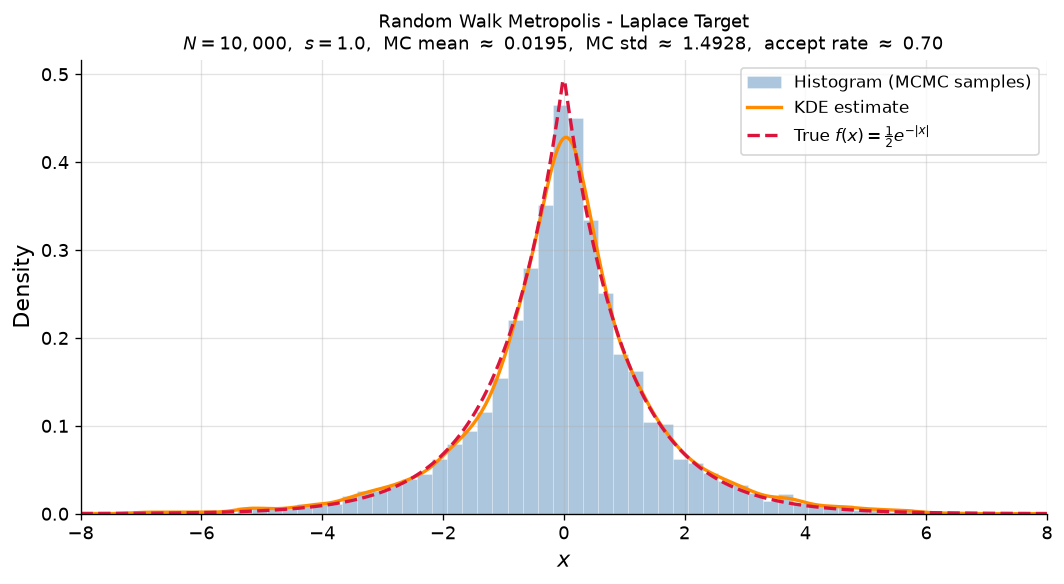

In [4]:
x_grid = np.linspace(-8, 8, 500)
kde    = gaussian_kde(samples_a, bw_method='scott')

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(samples_a, bins=60, density=True,
        color='steelblue', alpha=0.45, edgecolor='white', linewidth=0.4,
        label='Histogram (MCMC samples)')
ax.plot(x_grid, kde(x_grid),
        color='darkorange', linewidth=2.0, label='KDE estimate')
ax.plot(x_grid, target(x_grid),
        color='crimson', linewidth=2.0, linestyle='--',
        label=r'True $f(x)=\frac{1}{2}e^{-|x|}$')
ax.set_xlabel('$x$', fontsize=13)
ax.set_ylabel('Density', fontsize=13)
ax.set_title(
    f'Random Walk Metropolis - Laplace Target\n'
    f'$N={N_a:,}$,  $s={s_a}$,  '
    f'MC mean $\\approx$ {mc_mean:.4f},  '
    f'MC std $\\approx$ {mc_std:.4f},  '
    f'accept rate $\\approx$ {accept_rate:.2f}',
    fontsize=11,
)
ax.set_xlim(-8, 8)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### 1.b. Convergence diagnostic: $\hat{R}$ (Gelman-Rubin)

$$\hat{R} = \sqrt{\frac{B + W}{W}}, \quad W = \frac{1}{J}\sum_j V_j, \quad B = \frac{1}{J}\sum_j (M_j - M)^2$$

## Convergence diagnostics: $\hat{R}$ (Gelman–Rubin)

$$\hat{R} = \sqrt{\frac{B + W}{W}}, \quad W = \frac{1}{J}\sum_j V_j, \quad B = \frac{1}{J}\sum_j (M_j - M)^2$$

In [5]:
N_b, s_b, J = 2_000, 0.001, 4
initial_values = [-5.0, -1.0, 1.0, 5.0]

chains_b = []
for j, x0 in enumerate(initial_values):
    chain = random_walk_metropolis(N=N_b, s=s_b, x0=x0, seed=100 + j)
    chains_b.append(chain[1:])

rhat_b = compute_rhat(chains_b)
print(f"R-hat  (N={N_b}, s={s_b}, J={J}): {rhat_b:.4f}")
print(f"Converged (R-hat < 1.05)?  {'Yes' if rhat_b < 1.05 else 'No - poor mixing detected'}")

R-hat  (N=2000, s=0.001, J=4): 227.2722
Converged (R-hat < 1.05)?  No - poor mixing detected


With $s = 0.001$, each proposal step is $\sim 10^{-3}$, so chains started at $\{-5, -1, 1, 5\}$ remain near their starting points over 2,000 iterations. Between-chain variance dominates $\Rightarrow$ $\hat{R} \gg 1.05$.

#### Four-chain trace (N = 2,000, s = 0.001, J = 4)

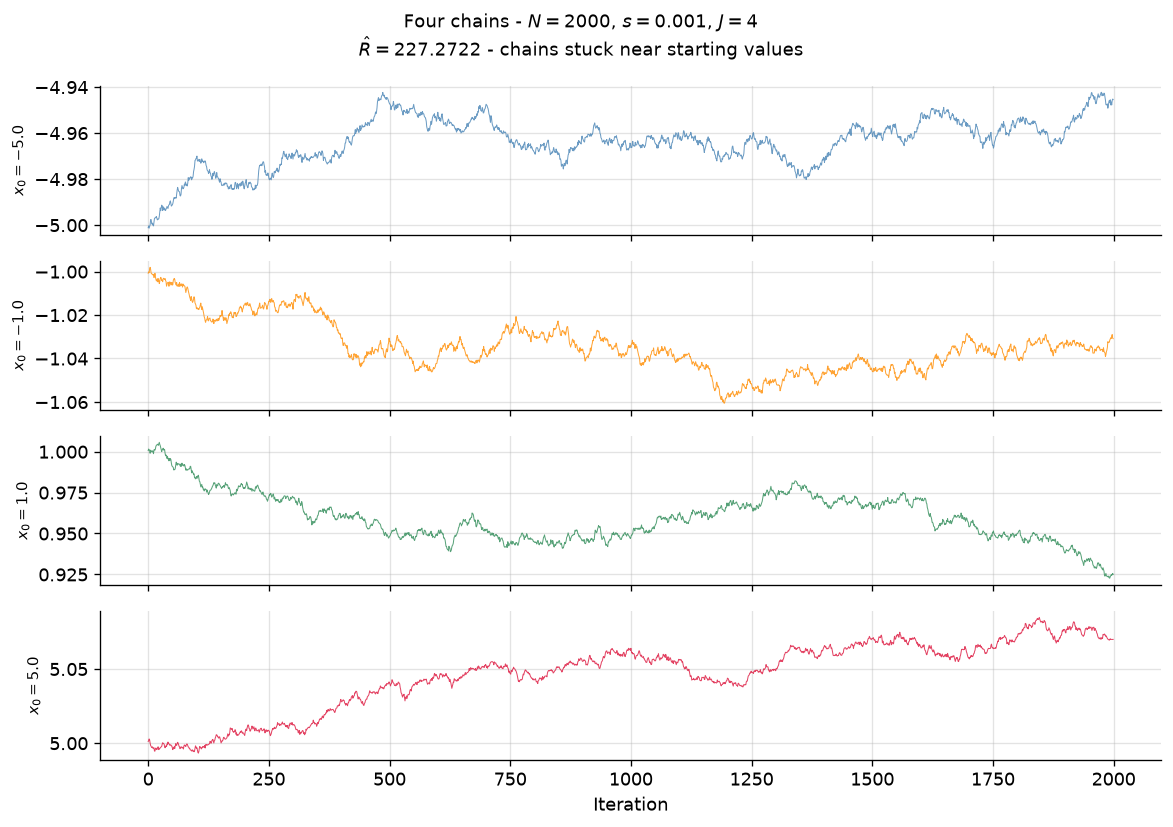

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(10, 7), sharex=True)
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']
for j, (chain, x0, col) in enumerate(zip(chains_b, initial_values, colors)):
    axes[j].plot(chain, color=col, linewidth=0.6, alpha=0.8)
    axes[j].set_ylabel(f'$x_0={x0}$', fontsize=9)
axes[-1].set_xlabel('Iteration', fontsize=11)
fig.suptitle(
    f'Four chains - $N={N_b}$, $s={s_b}$, $J={J}$\n'
    f'$\\hat{{R}} = {rhat_b:.4f}$ - chains stuck near starting values',
    fontsize=11,
)
plt.tight_layout()
plt.show()

#### $\hat{R}$ vs $s$ - log-spaced grid $[0.001,\, 1]$

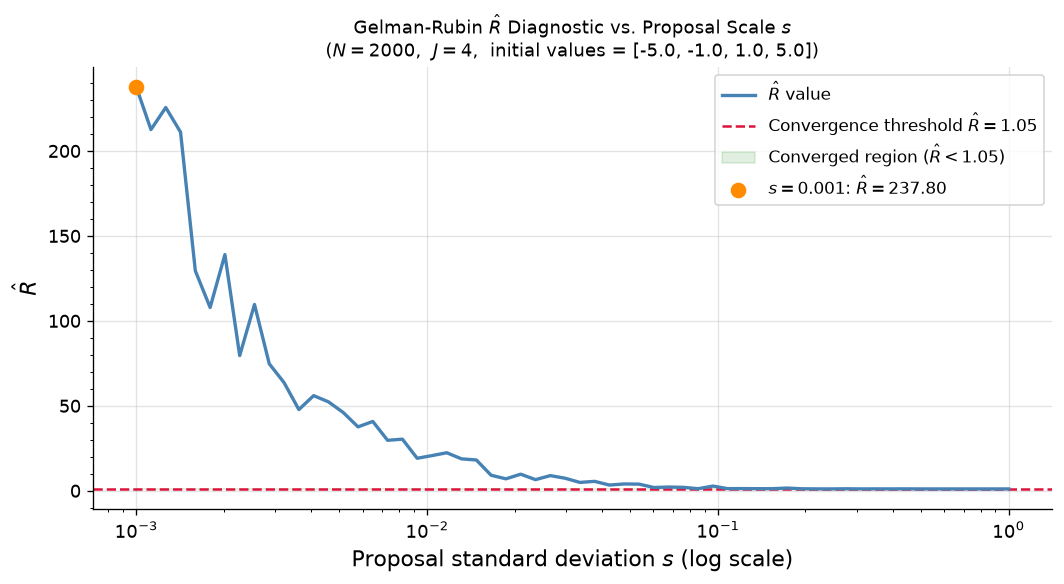

In [7]:
s_grid      = np.logspace(-3, 0, 60)   # log-spaced from 0.001 to 1
rhat_values = np.empty(len(s_grid))

for idx, s_val in enumerate(s_grid):
    chains = []
    for j, x0 in enumerate(initial_values):
        chain = random_walk_metropolis(N=N_b, s=s_val, x0=x0, seed=200 + idx * J + j)
        chains.append(chain[1:])
    rhat_values[idx] = compute_rhat(chains)

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(s_grid, rhat_values, color='steelblue', linewidth=2.0, zorder=3,
            label=r'$\hat{R}$ value')
ax.axhline(y=1.05, color='crimson', linestyle='--', linewidth=1.5,
           label=r'Convergence threshold $\hat{R} = 1.05$')
ax.fill_between(s_grid, 1.0, 1.05, alpha=0.12, color='green',
                label=r'Converged region ($\hat{R} < 1.05$)')
ax.scatter([s_b], [rhat_values[0]], color='darkorange', zorder=5, s=70,
           label=f'$s=0.001$: $\\hat{{R}}={rhat_values[0]:.2f}$')
ax.set_xlabel('Proposal standard deviation $s$ (log scale)', fontsize=13)
ax.set_ylabel(r'$\hat{R}$', fontsize=13)
ax.set_title(
    r'Gelman-Rubin $\hat{R}$ Diagnostic vs. Proposal Scale $s$' + '\n'
    + f'($N={N_b}$,  $J={J}$,  initial values = {initial_values})',
    fontsize=11,
)
ax.legend(fontsize=10)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
plt.tight_layout()
plt.show()

## Conclusion

The sampler mixes well for $s = 1$ (acceptance rate $\approx 0.70$, MC mean $\approx 0$, MC std $\approx \sqrt{2}$). For very small $s$ (e.g.\ $s = 0.001$), chains barely move and $\hat{R} \approx 227 \gg 1.05$; convergence is reached once $s \gtrsim 0.1$.